In [76]:
from sklearn.datasets import fetch_20newsgroups

categories = ["sci.med", "sci.space", "sci.electronics"]
newsgroups = fetch_20newsgroups(subset="train", categories=categories)
documents = newsgroups.data 
targets = newsgroups.target 
target_names = [newsgroups.target_names[i] for i in targets]

In [77]:
def explain_sample(sample_index): 
    print("CONTENT:")
    print(documents[sample_index])
    print("TARGET:", targets[sample_index])
    print("TARGET NAME:", target_names[sample_index])

    
explain_sample(1)


CONTENT:
From: markz@ssc.com (Mark Zenier)
Subject: Re: Can I use a CD4052 analog multiplexer for digital signals?
Organization: SSC, Inc.,  Seattle, WA
X-Newsreader: TIN [version 1.1 PL6]
Lines: 13

Tall Cool One (rky57514@uxa.cso.uiuc.edu) wrote:
: As the subject says - Can I use a 4052 for digital signals?  I don't see
: why it couldn't handle digital signals, but I could be wrong.  Anyone have
: any advice?  Thanks.

The switches have a non-negligable on resistance (up to 1k ohm when
powered by 5 volts) and a maximum current and a Maximum Static
Voltage Across Switch.  Not a good bet for TTL.  Should work for
CMOS, but slow things down a bit.  There are 74HC versions that
have better specs. but lower max voltage.

Mark Zenier  markz@ssc.wa.com  markz@ssc.com  


TARGET: 0
TARGET NAME: sci.electronics


In [78]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer="word", max_features=5000, stop_words= "english")
doc_term_matrix = vectorizer.fit_transform(documents)
print("Shape of doc_term_matrix:", doc_term_matrix.shape) # Should show (1778, 5000)

Shape of doc_term_matrix: (1778, 5000)


In [79]:
from sklearn.decomposition import TruncatedSVD 

# Initialize Truncated SVD with desired number of components (e.g., 500) 

n_components = 500 

svd_model = TruncatedSVD(n_components)

# Fit and transform the document-term matrix with Truncated SVD 
reduced_matrix = svd_model.fit_transform(doc_term_matrix)

print("Shape of reduced_matrix:", reduced_matrix.shape) # Should show (1778, 500)

Shape of reduced_matrix: (1778, 500)


In [80]:
import numpy as np 

print(np.sum(svd_model.explained_variance_ratio_[:]))

0.9313360447753527


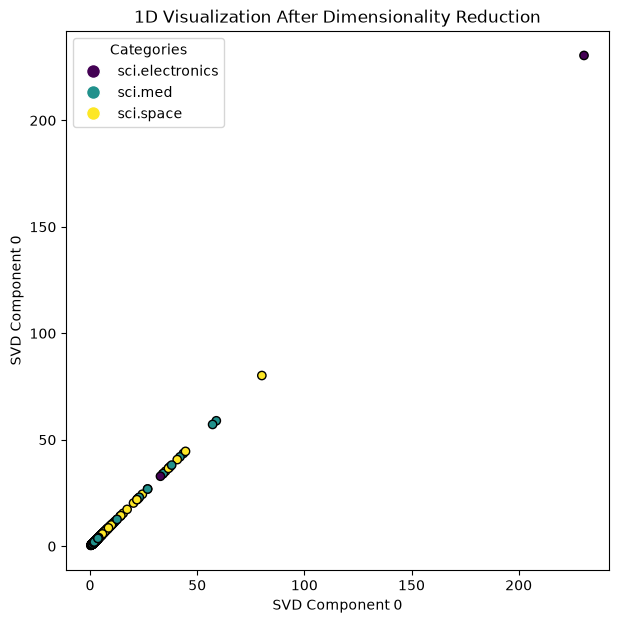

In [81]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7)) 
scatter = plt.scatter(reduced_matrix[:, 0], reduced_matrix[:, 0], c= 
  newsgroups.target, cmap="viridis", edgecolor="k")

plt.xlabel("SVD Component 0") 

plt.ylabel("SVD Component 0")

plt.title("1D Visualization After Dimensionality Reduction") 
legend_labels = {i: name for i, name in enumerate(newsgroups.target_names)} 
handles = [plt.Line2D([0], [0], marker="o", color="w", label=legend_labels[i 
   ], markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) for i in 
           legend_labels] 
plt.legend(handles=handles, title="Categories") 
plt.show()

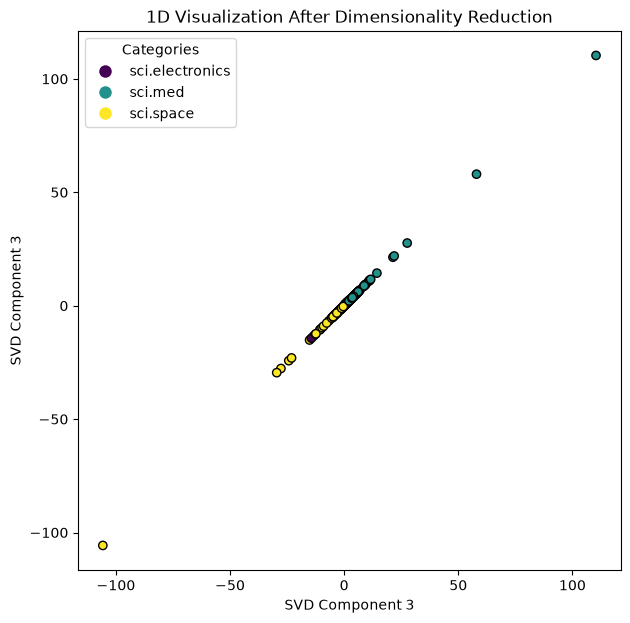

In [82]:
import matplotlib.pyplot as plt

def plot_1D(comp): 
    
    plt.figure(figsize=(7, 7)) 

    scatter = plt.scatter(reduced_matrix[:, comp], reduced_matrix[:, comp], c= 
  newsgroups.target, cmap="viridis", edgecolor="k")

    plt.xlabel("SVD Component 3") 

    plt.ylabel("SVD Component 3")

    plt.title("1D Visualization After Dimensionality Reduction")   
    legend_labels = {i: name for i, name in enumerate(newsgroups.target_names)} 
    handles = [plt.Line2D([0], [0], marker="o", color="w", label=legend_labels[i 
   ], markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) for i in 
           legend_labels] 
    plt.legend(handles=handles, title="Categories") 
    plt.show() 
plot_1D(3)

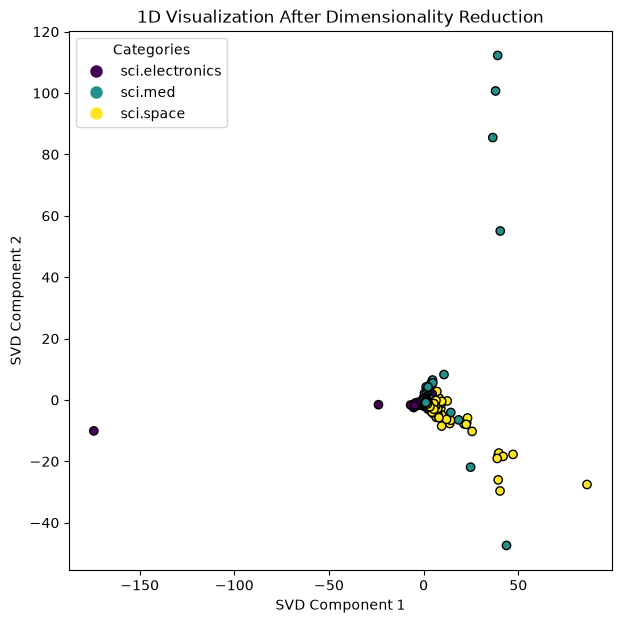

In [83]:
import matplotlib.pyplot as plt

def plot_2D(comp1, comp2): 
 
    
    plt.figure(figsize=(7, 7)) 

    scatter = plt.scatter(reduced_matrix[:, comp1], reduced_matrix[:, comp2], c= 
  newsgroups.target, cmap="viridis", edgecolor="k")

    plt.xlabel("SVD Component 1") 

    plt.ylabel("SVD Component 2")

    plt.title("1D Visualization After Dimensionality Reduction")   
    legend_labels = {i: name for i, name in enumerate(newsgroups.target_names)} 
    handles = [plt.Line2D([0], [0], marker="o", color="w", label=legend_labels[i 
   ], markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) for i in 
           legend_labels] 
    plt.legend(handles=handles, title="Categories") 
    plt.show() 

plot_2D(1,2)

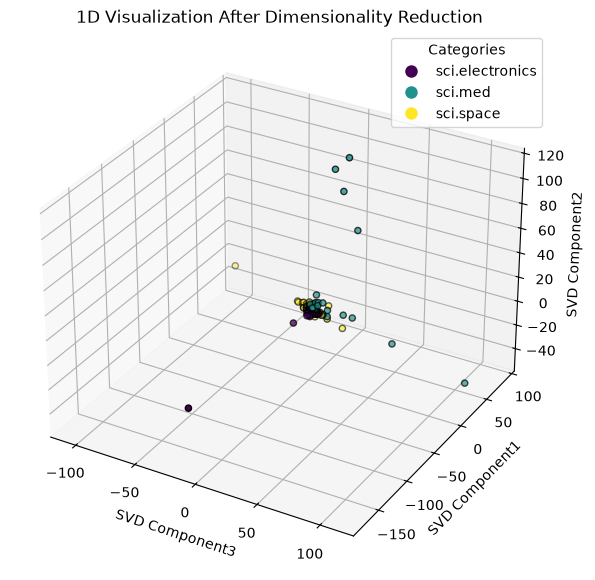

In [84]:
import matplotlib.pyplot as plt

def plot_3D(comp1, comp2, comp3): 
    
    X = reduced_matrix[:, comp1] 
    Y = reduced_matrix[:, comp2] 
    Z = reduced_matrix[:, comp3]
    
    fig = plt.figure(figsize=(7, 7))
    ax=fig.add_subplot(projection="3d")

    scatter = ax.scatter(X, Y, Z, c= newsgroups.target, cmap="viridis", edgecolor="k")

    ax.set_xlabel("SVD Component" + str (comp1)) 

    ax.set_ylabel("SVD Component" + str (comp2))
    
    ax.set_zlabel("SVD Component" + str (comp3))

    ax.set_title("1D Visualization After Dimensionality Reduction")   
    legend_labels = {i: name for i, name in enumerate(newsgroups.target_names)} 
    handles = [plt.Line2D([0], [0], marker="o", color="w", label=legend_labels[i 
   ], markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) for i in 
           legend_labels] 
    ax.legend(handles=handles, title="Categories") 
    plt.show() 
    
       
plot_3D(3,1,2)

In [85]:
newsgroups = fetch_20newsgroups(subset="train", categories=categories, remove=("headers", "footers", "quotes"))